In [1]:
#plotting

import pandas as pd
import os

base_path = r"C:\Users\aishw\.cache\kagglehub\datasets\wangboluo\pamap2\versions\1"

# Adjust file names if different
train_file = os.path.join(base_path, "train.csv")
test_file  = os.path.join(base_path, "test.csv")

train_df = pd.read_csv(train_file)
test_df  = pd.read_csv(test_file)

print("Train shape:", train_df.shape)
print("Test  shape:", test_df.shape)

print("\nTrain columns:\n", train_df.columns[:10], "...")
print("\nTrain sample:\n", train_df.head())


Train shape: (4489500, 38)
Test  shape: (1125500, 38)

Train columns:
 Index(['id', 'Activity', 'imu_hand_accX_16g', 'imu_hand_accY_16g',
       'imu_hand_accZ_16g', 'imu_hand_accX_6g', 'imu_hand_accY_6g',
       'imu_hand_accZ_6g', 'imu_hand_gyroX', 'imu_hand_gyroY'],
      dtype='object') ...

Train sample:
    id  Activity  imu_hand_accX_16g  imu_hand_accY_16g  imu_hand_accZ_16g  \
0   1         0           0.661126           0.421296           0.408697   
1   1         0           0.661284           0.421581           0.408104   
2   1         0           0.661837           0.421871           0.408258   
3   1         0           0.662559           0.421429           0.408268   
4   1         0           0.661320           0.422026           0.408845   

   imu_hand_accX_6g  imu_hand_accY_6g  imu_hand_accZ_6g  imu_hand_gyroX  \
0          0.471288          0.541375          0.537667        0.536450   
1          0.471682          0.541373          0.537545        0.535625   
2     

In [2]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

In [3]:
drop_cols = ['id','Activity']
feature_cols = [c for c in train_df.columns if c not in drop_cols and np.issubdtype(train_df[c].dtype, np.number)]

X_train = train_df[feature_cols].values
X_test  = test_df[feature_cols].values
y_test  = np.where(test_df['Activity']==0, -1, 1)


In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


In [5]:
frac = 0.02  # use 2% of training data
idx = np.random.choice(len(X_train_scaled), size=int(frac*len(X_train_scaled)), replace=False)
X_train_frac = X_train_scaled[idx]

In [6]:
ocsvm = OneClassSVM(kernel='linear', nu=0.05)
ocsvm.fit(X_train_frac)


OneClassSVM(kernel='linear', nu=0.05)

In [7]:
y_pred = ocsvm.predict(X_test_scaled)

In [8]:
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred, labels=[1,-1])
anomaly_count = np.sum(y_pred==-1)

print(f"Accuracy: {accuracy*100:.2f}%")
print(f"Anomalies detected: {anomaly_count} / {len(y_pred)}")
print("Confusion Matrix:\n", cm)

Accuracy: 42.59%
Anomalies detected: 576862 / 1125500
Confusion Matrix:
 [[329987 427513]
 [218651 149349]]


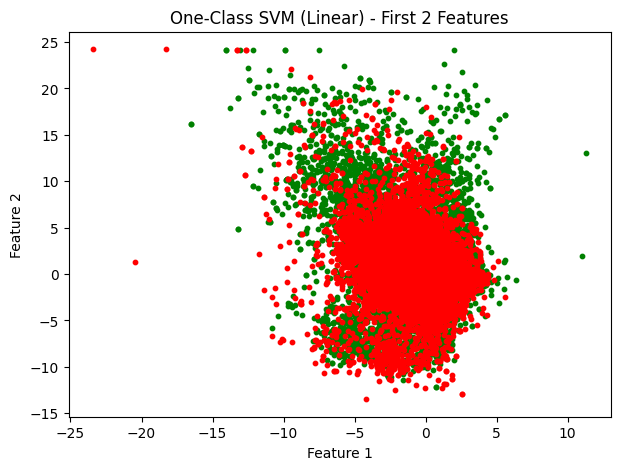

In [9]:
plt.figure(figsize=(7,5))
plt.scatter(X_test_scaled[y_pred==1,0], X_test_scaled[y_pred==1,1], s=10, c='green')
plt.scatter(X_test_scaled[y_pred==-1,0], X_test_scaled[y_pred==-1,1], s=10, c='red')
plt.title("One-Class SVM (Linear) - First 2 Features")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [10]:
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred, labels=[1, -1], target_names=['Normal', 'Anomaly'])
print(report)

              precision    recall  f1-score   support

      Normal       0.60      0.44      0.51    757500
     Anomaly       0.26      0.41      0.32    368000

    accuracy                           0.43   1125500
   macro avg       0.43      0.42      0.41   1125500
weighted avg       0.49      0.43      0.44   1125500

